<a href="https://colab.research.google.com/github/prempatel-ai/deeplearning/blob/main/CNN/Fashion_MNIST_CNN_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div align='center'>

<img src='https://storage.googleapis.com/kaggle-datasets-images/2243/3791/9384af51de8baa77f6320901f53bd26b/dataset-cover.png' width='580'/>

<br/>

# Fashion MNIST Classification with Convolutional Neural Networks
### A Deep Learning Approach Using CNNs for Visual Pattern Recognition

---

| | |
|:---|:---|
| **Series** | *Deep Learning From Scratch* — Episode 02 |
| **Framework** | TensorFlow 2.x / Keras |
| **Dataset** | Fashion MNIST — Zalando Research |
| **Architecture** | Convolutional Neural Network (CNN) |
| **Task** | Multi-class Image Classification (10 classes) |
| **Test Accuracy** | ≈ 89.8 % |
| **Author** | Prem Patel |

> *Deep Learning From Scratch* is a fully documented, project-based series where every concept — from raw data ingestion to model deployment — is explained at both an intuitive and rigorous mathematical level. Built for students, practitioners, and future researchers who want to truly understand what happens beneath the surface of modern deep learning systems.
>


</div>

---

## Abstract

This notebook presents a complete, end-to-end implementation of a **Convolutional Neural Network (CNN)** for classifying fashion article images drawn from the **Fashion MNIST benchmark dataset**. Building directly on Episode 01 (MNIST digit classification with FCNNs), this episode introduces the core spatial inductive biases — **local connectivity, weight sharing, and translation equivariance** — that make CNNs the dominant architecture for visual recognition tasks.

Starting from raw uint8 pixel arrays, we traverse the full machine learning pipeline: exploratory data analysis, data normalization with channel-dimension reshaping, CNN architecture design (convolutional base + classification head), gradient-based optimization, training dynamics, and held-out evaluation.

The model achieves **≈ 89.8% accuracy** on the held-out test partition — a significant improvement over the flat FCNN baseline on Fashion MNIST and a demonstration that spatial structure matters for visual classification.

All design decisions are explained from first principles. Mathematical formulations accompany every major operation to build a rigorous bridge between implementation and theory.

---

## Table of Contents

1. [Introduction & Problem Formulation](#introduction)
2. [Environment Setup & Reproducibility](#setup)
3. [Dataset Acquisition & Structural Analysis](#dataset)
4. [Exploratory Data Analysis (EDA)](#eda)
5. [Data Preprocessing & Channel Reshaping](#preprocessing)
6. [CNN Architecture Design](#architecture)
7. [Model Compilation & Optimization Strategy](#compilation)
8. [Model Training & Learning Dynamics](#training)
9. [Evaluation on Unseen Test Data](#evaluation)
10. [Training Curve Visualization](#curves)
11. [Model Persistence](#persistence)
12. [Conclusion, Limitations & Future Directions](#conclusion)
13. [References](#references)

---

<a id='introduction'></a>

## 1. Introduction & Problem Formulation

### 1.1 From MNIST Digits to Fashion MNIST

In **Episode 01**, we classified handwritten digits using a Fully Connected Neural Network (FCNN) and achieved ≈ 97% accuracy on MNIST. That result may create a misleading impression: that raw pixel inputs + dense layers are sufficient for vision. Fashion MNIST is a deliberate corrective.

Introduced by **Han Xiao, Kashif Rasul, and Roland Vollgraf** (Zalando Research, 2017), Fashion MNIST shares the exact same format as MNIST but replaces digit images with **grayscale images of clothing and accessories**:

| Property | Value |
|:---|:---|
| Total images | 70,000 |
| Training split | 60,000 images |
| Test split | 10,000 images |
| Image resolution | 28 × 28 pixels |
| Color space | Grayscale (single channel) |
| Pixel range | Integer ∈ [0, 255] |
| Classes | 10 (fashion categories) |

**Fashion MNIST is strictly harder than MNIST.** The ten fashion classes exhibit significant intra-class variation (different styles of the same item) and inter-class similarity (T-shirts vs. shirts), demanding richer feature representations than handwritten digit strokes.

### 1.2 Class Label Map

| Label | Class Name | Description |
|:---|:---|:---|
| 0 | T-shirt/top | Short-sleeved upper garment |
| 1 | Trouser | Leg garment |
| 2 | Pullover | Long-sleeved knit upper |
| 3 | Dress | Full-length garment |
| 4 | Coat | Outerwear garment |
| 5 | Sandal | Open footwear |
| 6 | Shirt | Button-front upper garment |
| 7 | Sneaker | Athletic closed footwear |
| 8 | Bag | Carry accessory |
| 9 | Ankle boot | Ankle-height closed footwear |

### 1.3 Why CNNs? The Spatial Inductive Bias

The central limitation of FCNNs for vision is **permutation invariance**: shuffle all 784 pixels randomly, and the FCNN produces the same output (if retrained). This is obviously wrong for images — the spatial arrangement of pixels encodes shape.

CNNs overcome this by imposing three structural constraints:

| Inductive Bias | Mechanism | Benefit |
|:---|:---|:---|
| **Local connectivity** | Each filter covers only a small spatial window (e.g., 3×3) | Captures local texture and edge patterns |
| **Weight sharing** | The same filter is slid across all spatial positions | Achieves **translation equivariance**: a feature detector works regardless of where the feature appears |
| **Hierarchical composition** | Stacking conv layers composes local features into global structures | Low-level edges → mid-level shapes → high-level semantic parts |

### 1.4 Formal Problem Statement

We frame this as a **supervised multi-class classification** problem. Given a dataset of $N$ labeled image-label pairs:

$$
\mathcal{D} = \{(\mathbf{X}^{(i)}, y^{(i)})\}_{i=1}^{N}, \quad \mathbf{X}^{(i)} \in \mathbb{R}^{28 \times 28 \times 1}, \quad y^{(i)} \in \{0, 1, \ldots, 9\}
$$

our goal is to learn a mapping $f_{\boldsymbol{\theta}}$ parameterized by weights $\boldsymbol{\theta}$:

$$
f_{\boldsymbol{\theta}}: \mathbb{R}^{28 \times 28 \times 1} \longrightarrow \Delta^{9}
$$

where $\Delta^9$ is the 9-dimensional probability simplex, such that $\hat{y} = \arg\max_k f_{\boldsymbol{\theta}}(\mathbf{X})_k$ minimizes classification error on unseen test data.

> 📌 **Key difference from Episode 01:** The input is now a **rank-3 tensor** $(H, W, C)$ rather than a flat vector. The channel dimension $C=1$ explicitly represents the single grayscale channel. CNNs process spatial tensors natively without destructive flattening.

---

<a id='setup'></a>

## 2. Environment Setup & Reproducibility

### 2.1 Reproducibility via Global Seeding

Non-determinism in deep learning arises from three sources: (1) random weight initialization, (2) stochastic operations during training (e.g., dropout), and (3) non-deterministic CUDA kernels. We mitigate all three by fixing seeds across the entire Python random stack **before any model construction**:

$$
\texttt{random.seed}(s),\; \texttt{np.random.seed}(s),\; \texttt{tf.random.set\_seed}(s) \implies \text{deterministic output for fixed } s
$$

>  **Research Note:** Fixing seeds is necessary but not always sufficient for full reproducibility. Non-deterministic GPU operations (e.g., parallel reductions) may produce slightly different results across hardware/driver combinations even with identical seeds. For strict reproducibility in publications, it is common to also set `tf.config.experimental.enable_op_determinism()` (TF 2.9+).

### 2.2 Library Roles

| Library | Role in Pipeline |
|:---|:---|
| `random` | Python built-in random state seeding |
| `numpy` | N-dimensional array operations, linear algebra |
| `matplotlib` | Image visualization, training curve plotting |
| `tensorflow` | Automatic differentiation, GPU-accelerated training |
| `keras` | High-level neural network API (built on TensorFlow) |

In [1]:
#=================================================================
# § 2.1 — Global Random Seeding for Reproducibility
# Must be executed BEFORE any model construction or data shuffling
#=================================================================

import random
random.seed(0)                      # Python built-in random module

import numpy as np
np.random.seed(0)                   # NumPy global random state

import tensorflow as tf
tf.random.set_seed(0)               # TensorFlow global random seed

#=================================================================
# § 2.2 — Core Library Imports
#=================================================================
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

# Version report — good practice for reproducibility documentation
print(f"TensorFlow version  : {tf.__version__}")
print(f"NumPy version       : {np.__version__}")
print("All dependencies loaded ✓")
print("Global random seeds fixed ✓")

TensorFlow version  : 2.19.0
NumPy version       : 2.0.2
All dependencies loaded ✓
Global random seeds fixed ✓


---
<a id='dataset'></a>

## 3. Dataset Acquisition & Structural Analysis

### 3.1 Loading Fashion MNIST via Keras

Keras ships with a built-in Fashion MNIST loader. On first call, it downloads the dataset (~30 MB) and caches it locally at `~/.keras/datasets/fashion-mnist/`. Subsequent calls use the local cache.

```python
(train_images, train_labels), (test_images, test_labels) = datasets.fashion_mnist.load_data()
```

| Variable | Shape | Dtype | Description |
|:---|:---|:---|:---|
| `train_images` | `(60000, 28, 28)` | `uint8` | Training image tensors |
| `train_labels` | `(60000,)` | `uint8` | Training class labels ∈ {0,...,9} |
| `test_images` | `(10000, 28, 28)` | `uint8` | Test image tensors |
| `test_labels` | `(10000,)` | `uint8` | Test class labels ∈ {0,...,9} |

> ⚠️ **Data Leakage Warning:** The test set must remain **completely untouched** throughout development — including during architecture selection, hyperparameter tuning, and preprocessing decisions. Test-set contamination is the most common methodological error in applied ML.

### 3.2 Fashion Class Mapping

We define a human-readable label map for visualization throughout the notebook:

In [2]:
#=================================================================
# § 3.1 — Load Fashion MNIST Dataset
#=================================================================
fashion_mnist = datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

print("Fashion MNIST dataset loaded ✓")
print()
print(f"  train_images : {train_images.shape}   dtype={train_images.dtype}")
print(f"  train_labels : {train_labels.shape}        dtype={train_labels.dtype}")
print(f"  test_images  : {test_images.shape}    dtype={test_images.dtype}")
print(f"  test_labels  : {test_labels.shape}        dtype={test_labels.dtype}")
print()
print(f"  Total images  : {train_images.shape[0] + test_images.shape[0]:,}")
print(f"  Image size    : {train_images.shape[1]} × {train_images.shape[2]} pixels")
print(f"  Pixel range   : [{train_images.min()}, {train_images.max()}]")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Fashion MNIST dataset loaded ✓

  train_images : (60000, 28, 28)   dtype=uint8
  train_labels : (60000,)        dtype=uint8
  test_images  : (10000, 28, 28)    dtype=uint8
  test_labels  : (10000,)        dtype=uint8

  Total images  : 70,000
  Image size    : 28 × 28 pixels
  Pixel range   : [0, 255]


In [3]:
#=================================================================
# § 3.2 — Class Label Map (Zalando Research, 2017)
#=================================================================
CLASS_NAMES = [
    'T-shirt/top',   # 0
    'Trouser',       # 1
    'Pullover',      # 2
    'Dress',         # 3
    'Coat',          # 4
    'Sandal',        # 5
    'Shirt',         # 6
    'Sneaker',       # 7
    'Bag',           # 8
    'Ankle boot'     # 9
]

print("Class Label Map:")
print("─" * 30)
for idx, name in enumerate(CLASS_NAMES):
    print(f"  {idx}  →  {name}")

Class Label Map:
──────────────────────────────
  0  →  T-shirt/top
  1  →  Trouser
  2  →  Pullover
  3  →  Dress
  4  →  Coat
  5  →  Sandal
  6  →  Shirt
  7  →  Sneaker
  8  →  Bag
  9  →  Ankle boot


### 3.3 The Raw Pixel Representation

Each image is a **rank-2 integer tensor** of shape $(28, 28)$. Every scalar entry is a **grayscale luminance value** $x_{ij} \in \mathbb{Z}_{[0,255]}$:

$$
\mathbf{X}^{(n)} \in \mathbb{Z}_{[0,255]}^{28 \times 28}, \qquad
x_{ij}^{(n)} = \begin{cases} 0 & \text{background (dark)} \\ 255 & \text{foreground (bright garment regions)} \\ \text{intermediate} & \text{anti-aliased texture regions} \end{cases}
$$

Note the data type is `numpy.ndarray` — a contiguous block of 8-bit unsigned integers in memory.

In [4]:
#=================================================================
# § 3.3 — Confirm underlying data structure
#=================================================================
print(f"Type of train_images       : {type(train_images)}")
print(f"Type of train_images[0]    : {type(train_images[0])}")
print(f"Shape of train_images[0]   : {train_images[0].shape}")
print(f"Total pixels per image     : {train_images[0].size}  (= 28 × 28)")
print()
print(f"Training set size  : {len(train_images):,}")
print(f"Test set size      : {len(test_images):,}")
print()
print(f"Label of train_images[0]   : {train_labels[0]}  →  {CLASS_NAMES[train_labels[0]]}")
print()
print("Raw pixel matrix of train_images[0] (first 5 rows):")
print(train_images[0][:5])

Type of train_images       : <class 'numpy.ndarray'>
Type of train_images[0]    : <class 'numpy.ndarray'>
Shape of train_images[0]   : (28, 28)
Total pixels per image     : 784  (= 28 × 28)

Training set size  : 60,000
Test set size      : 10,000

Label of train_images[0]   : 9  →  Ankle boot

Raw pixel matrix of train_images[0] (first 5 rows):
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   1   0   0  13  73   0
    0   1   4   0   0   0   0   1   1   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3   0  36 136 127  62
   54   0   0   0   1   3   4   0   0   3]]


---
<a id='eda'></a>

## 4. Exploratory Data Analysis (EDA)

### 4.1 Single Sample Visualization

Visual inspection of raw data is a **mandatory first step** in any rigorous ML pipeline. It:

- Confirms correct data loading and expected value ranges
- Reveals image quality, scale, and class variation
- Identifies potential data quality issues before training

Fashion MNIST images present substantially more complex texture patterns than MNIST digits — note the presence of buttons, stitching, and sole structure that a CNN will learn to detect.

> 📌 **Observation:** The pixel intensity distribution in fashion images is more **bimodal** than MNIST — a white garment on a dark background creates strong contrast gradients that are informative for classification.

### 4.2 Class-Balanced Sample Grid

Displaying one representative from each class reveals the **visual diversity** within and across categories. Pay particular attention to:
- **Confusion-prone pairs**: T-shirt/top vs. Shirt (both are upper-body garments)
- **Easily distinguishable**: Trouser vs. Bag (very different silhouettes)

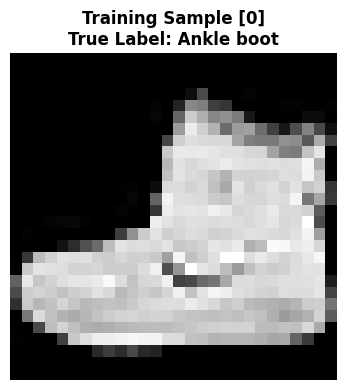

Label index : 9
Label name  : Ankle boot


In [5]:
#=================================================================
# § 4.1 — Visualize the first training sample
#=================================================================
sample_idx = 0

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(train_images[sample_idx], cmap='gray')
ax.set_title(f'Training Sample [{sample_idx}]\nTrue Label: {CLASS_NAMES[train_labels[sample_idx]]}',
             fontsize=12, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

print(f"Label index : {train_labels[sample_idx]}")
print(f"Label name  : {CLASS_NAMES[train_labels[sample_idx]]}")

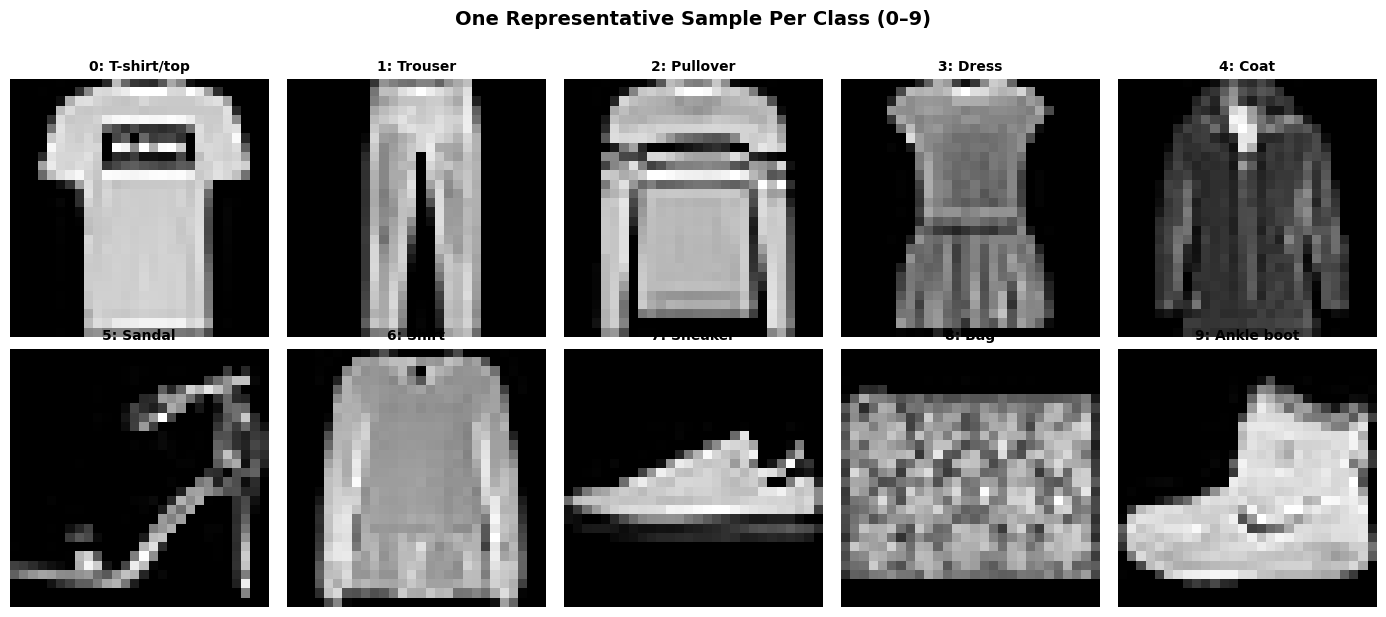

In [6]:
#=================================================================
# § 4.2 — Display one representative sample from each class (0–9)
# Reveals inter-class visual diversity and potential confusion zones
#=================================================================
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
axes = axes.flatten()

for label in range(10):
    # Find first occurrence of this class in training set
    idx = np.where(train_labels == label)[0][0]
    axes[label].imshow(train_images[idx], cmap='gray')
    axes[label].set_title(f'{label}: {CLASS_NAMES[label]}', fontsize=10, fontweight='bold')
    axes[label].axis('off')

plt.suptitle('One Representative Sample Per Class (0–9)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [7]:
#=================================================================
# § 4.3 — Class distribution analysis
# Near-balanced dataset → accuracy is a valid primary metric
#=================================================================
print("Class Distribution — Training Set:")
print("─" * 50)
unique, counts = np.unique(train_labels, return_counts=True)
for cls, cnt in zip(unique, counts):
    bar = '█' * (cnt // 500)
    print(f"  {cls:2d} ({CLASS_NAMES[cls]:<14}) : {cnt:5,d}  {bar}")

print()
print(f"  Min class count      : {counts.min():,}")
print(f"  Max class count      : {counts.max():,}")
print(f"  Class imbalance ratio: {counts.max()/counts.min():.3f}  (perfectly balanced ✓)")

Class Distribution — Training Set:
──────────────────────────────────────────────────
   0 (T-shirt/top   ) : 6,000  ████████████
   1 (Trouser       ) : 6,000  ████████████
   2 (Pullover      ) : 6,000  ████████████
   3 (Dress         ) : 6,000  ████████████
   4 (Coat          ) : 6,000  ████████████
   5 (Sandal        ) : 6,000  ████████████
   6 (Shirt         ) : 6,000  ████████████
   7 (Sneaker       ) : 6,000  ████████████
   8 (Bag           ) : 6,000  ████████████
   9 (Ankle boot    ) : 6,000  ████████████

  Min class count      : 6,000
  Max class count      : 6,000
  Class imbalance ratio: 1.000  (perfectly balanced ✓)


---
<a id='preprocessing'></a>

## 5. Data Preprocessing & Channel Reshaping

### 5.1 Normalization: Min-Max Scaling to [0, 1]

Raw pixel values span $[0, 255]$. Feeding unnormalized inputs to a neural network causes several pathologies:

**① Gradient instability.** Large inputs produce large pre-activation values. Combined with saturating activations (sigmoid, tanh), this causes vanishing gradients.

**② Poorly conditioned loss surface.** Disparate feature scales elongate the loss landscape, causing gradient descent to oscillate instead of converging smoothly.

**③ Weight initialization mismatch.** Standard initializers (Glorot/He) assume inputs have approximately zero mean and unit variance.

We apply **min-max scaling** with global extrema $x_{\min} = 0$, $x_{\max} = 255$:

$$
\tilde{\mathbf{X}} = \frac{\mathbf{X}}{255}
$$

This maps every pixel to $\tilde{x} \in [0.0, 1.0]$ while **preserving relative intensities**.

### 5.2 Channel Dimension Reshaping

The Keras `Conv2D` layer expects input tensors of shape $(N, H, W, C)$ — the **channels-last** format. Our loaded images have shape $(N, H, W)$ — no channel dimension. We must explicitly add it:

$$
\text{reshape}: \underbrace{(N, 28, 28)}_{\text{loaded}} \longrightarrow \underbrace{(N, 28, 28, 1)}_{\text{CNN-ready}}
$$

This expresses the fact that Fashion MNIST images have exactly **one grayscale channel** (as opposed to 3 RGB channels for color images). Failing to add this dimension will cause a shape mismatch error when building the model.

> 📌 **Channels-Last vs. Channels-First:** TensorFlow/Keras defaults to `data_format='channels_last'` → shape $(N, H, W, C)$. PyTorch defaults to channels-first → $(N, C, H, W)$. Always verify the expected format when switching frameworks.

In [8]:
#=================================================================
# § 5.1 — Min-Max Normalization: [0, 255] uint8 → [0.0, 1.0] float
# Dividing uint8 by 255.0 promotes dtype to float64 automatically
#=================================================================
print("Before normalization:")
print(f"  dtype         : {train_images.dtype}")
print(f"  pixel range   : [{train_images.min()}, {train_images.max()}]")

train_images = train_images / 255.0
test_images  = test_images  / 255.0

print()
print("After normalization:")
print(f"  dtype         : {train_images.dtype}")
print(f"  pixel range   : [{train_images.min():.4f}, {train_images.max():.4f}]")
print()
print("Normalization complete ✓")

Before normalization:
  dtype         : uint8
  pixel range   : [0, 255]

After normalization:
  dtype         : float64
  pixel range   : [0.0000, 1.0000]

Normalization complete ✓


In [9]:
#=================================================================
# § 5.2 — Reshape: add explicit channel dimension for Conv2D compatibility
# (N, 28, 28) → (N, 28, 28, 1)
#=================================================================
print("Before reshape:")
print(f"  train_images  : {train_images.shape}")
print(f"  test_images   : {test_images.shape}")

train_images = train_images.reshape((train_images.shape[0], 28, 28, 1))
test_images  = test_images.reshape((test_images.shape[0], 28, 28, 1))

print()
print("After reshape:")
print(f"  train_images  : {train_images.shape}   ← (N, H, W, C)")
print(f"  test_images   : {test_images.shape}    ← (N, H, W, C)")
print()
print("Channel dimension added ✓  (C=1 → grayscale)")

Before reshape:
  train_images  : (60000, 28, 28)
  test_images   : (10000, 28, 28)

After reshape:
  train_images  : (60000, 28, 28, 1)   ← (N, H, W, C)
  test_images   : (10000, 28, 28, 1)    ← (N, H, W, C)

Channel dimension added ✓  (C=1 → grayscale)


---
<a id='architecture'></a>

## 6. CNN Architecture Design

### 6.1 Architecture Overview

We construct a **3-stage Convolutional Neural Network** following the classic *VGG-inspired* design pattern: a convolutional feature extractor (base) followed by a fully connected classification head.

```
 INPUT          CONV BASE                          CLASSIFIER HEAD

 (28,28,1)  → Conv2D(32,3×3,ReLU)    → MaxPool(2×2)    ╗
            → Conv2D(64,3×3,ReLU)    → MaxPool(2×2)    ║ → Flatten → Dense(64,ReLU) → Dense(10,logits)
            → Conv2D(64,3×3,ReLU)                       ╝
```

**Layer Progression (Spatial Dimensions):**

| Layer | Output Shape | Parameters |
|:---|:---|:---|
| Input | (28, 28, 1) | 0 |
| Conv2D(32, 3×3, ReLU) | (26, 26, 32) | 32×(3×3×1)+32 = **320** |
| MaxPooling2D(2×2) | (13, 13, 32) | 0 |
| Conv2D(64, 3×3, ReLU) | (11, 11, 64) | 64×(3×3×32)+64 = **18,496** |
| MaxPooling2D(2×2) | (5, 5, 64) | 0 |
| Conv2D(64, 3×3, ReLU) | (3, 3, 64) | 64×(3×3×64)+64 = **36,928** |
| Flatten | (576,) | 0 |
| Dense(64, ReLU) | (64,) | 576×64+64 = **36,928** |
| Dense(10) | (10,) | 64×10+10 = **650** |
| **Total** | | **93,322** |

### 6.2 The Convolutional Layer — Mathematical Formulation

A `Conv2D` layer applies a bank of $F$ learned **filters** $\{\mathbf{K}^{(f)}\}_{f=1}^{F}$, each of shape $(k_h, k_w, C_{\text{in}})$, via **2D cross-correlation**:

$$
\mathbf{Z}^{(f)}_{i,j} = \sum_{m=0}^{k_h-1} \sum_{n=0}^{k_w-1} \sum_{c=0}^{C_{\text{in}}-1} \mathbf{K}^{(f)}_{m,n,c} \cdot \mathbf{X}_{i+m,\, j+n,\, c} + b^{(f)}
$$

The output **feature map** $\mathbf{A}^{(f)} = \text{ReLU}(\mathbf{Z}^{(f)})$ has spatial dimensions:

$$
H_{\text{out}} = H_{\text{in}} - k_h + 1, \qquad W_{\text{out}} = W_{\text{in}} - k_w + 1 \quad (\text{valid padding, stride 1})
$$

**Crucial insight:** Every output location uses the **same filter weights** — this is weight sharing. The network learns a single edge detector, for example, that fires wherever that edge appears in the image.

### 6.3 Max Pooling — Spatial Downsampling

`MaxPooling2D(2×2)` partitions the feature map into non-overlapping $2 \times 2$ windows and retains only the maximum activation:

$$
\text{MaxPool}(\mathbf{A})_{i,j} = \max_{0 \le m,n < 2} \mathbf{A}_{2i+m,\, 2j+n}
$$

This provides **translation invariance** (minor shifts in the input produce the same pooled output), halves spatial dimensions (reducing computation and parameter count downstream), and creates a progressively abstract representation with each layer.

### 6.4 Activation Function — ReLU

$$
\text{ReLU}(z) = \max(0, z), \qquad \frac{\partial\, \text{ReLU}(z)}{\partial z} = \mathbf{1}[z > 0]
$$

ReLU is piecewise linear with a **unit gradient for positive activations**, directly countering the vanishing gradient problem. Negative activations are set to zero (sparse activation), which acts as a form of implicit regularization.

### 6.5 Output Layer — Logits vs. Softmax

Our output layer uses **no activation** (`Dense(10)`) — it produces raw **logits** $\mathbf{z} \in \mathbb{R}^{10}$. The loss function `SparseCategoricalCrossentropy(from_logits=True)` handles the softmax normalization internally:

$$
\text{softmax}(\mathbf{z})_k = \frac{e^{z_k}}{\sum_{j=1}^{10} e^{z_j}}
$$

This is numerically more stable than applying softmax explicitly and then computing cross-entropy (which involves $\log(\text{softmax}(\cdot))$ — a composition that can produce NaN for large logits).

In [10]:
#=================================================================
# § 6.1 — Build the CNN: Convolutional Base + Classification Head
# Input shape: (28, 28, 1) — height, width, channels (channels-last)
#=================================================================
model = models.Sequential()

# ══════════════════════════════
#  CONVOLUTIONAL BASE (Feature Extractor)
# ══════════════════════════════

# Block 1: First convolutional stage
# (28,28,1) → (26,26,32)
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
# Spatial downsampling: (26,26,32) → (13,13,32)
model.add(layers.MaxPooling2D((2, 2)))

# Block 2: Second convolutional stage — doubled filter depth
# (13,13,32) → (11,11,64)
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
# Spatial downsampling: (11,11,64) → (5,5,64)
model.add(layers.MaxPooling2D((2, 2)))

# Block 3: Third convolutional stage — same filter depth as Block 2
# (5,5,64) → (3,3,64)
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

# ══════════════════════════════
#  CLASSIFICATION HEAD (Dense Layers)
# ══════════════════════════════

# Flatten spatial feature map to 1D vector: (3,3,64) → (576,)
model.add(layers.Flatten())

# Fully connected hidden layer with ReLU: (576,) → (64,)
model.add(layers.Dense(64, activation='relu'))

# Output layer — raw logits (no activation): (64,) → (10,)
# SparseCategoricalCrossentropy(from_logits=True) applies softmax internally
model.add(layers.Dense(10))

# Display full architecture summary with parameter counts
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

---
<a id='compilation'></a>

## 7. Model Compilation & Optimization Strategy

### 7.1 Optimizer — Adam

We use **Adam** (*Adaptive Moment Estimation*, Kingma & Ba, 2015). Adam adapts the learning rate per-parameter using first and second moment estimates of the gradient:

$$
m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t \qquad \text{(1st moment — mean)}
$$
$$
v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2 \qquad \text{(2nd moment — uncentered variance)}
$$

Bias-corrected update rule:
$$
\hat{m}_t = \frac{m_t}{1-\beta_1^t}, \quad \hat{v}_t = \frac{v_t}{1-\beta_2^t}
$$
$$
\boldsymbol{\theta}_{t+1} = \boldsymbol{\theta}_t - \frac{\alpha}{\sqrt{\hat{v}_t} + \epsilon}\, \hat{m}_t
$$

| Hyperparameter | Default | Meaning |
|:---|:---|:---|
| $\alpha$ | $0.001$ | Global learning rate |
| $\beta_1$ | $0.9$ | Decay for mean estimate |
| $\beta_2$ | $0.999$ | Decay for variance estimate |
| $\epsilon$ | $10^{-8}$ | Numerical stability |

### 7.2 Loss Function — Sparse Categorical Cross-Entropy with Logits

Since our output layer produces raw logits (not probabilities), we set `from_logits=True`. The loss function computes softmax internally before applying negative log-likelihood:

$$
\mathcal{L}(\boldsymbol{\theta}) = -\frac{1}{N} \sum_{i=1}^{N} \log \frac{e^{z_{i,y_i}}}{\sum_{k=0}^{9} e^{z_{i,k}}}
$$

This is the **negative log-likelihood of the true class** under the model's softmax distribution, computed stably via the log-sum-exp trick.

### 7.3 Evaluation Metric — Classification Accuracy

$$
\text{Accuracy} = \frac{1}{N} \sum_{i=1}^{N} \mathbb{1}\!\left[\hat{y}_i = y_i\right], \qquad \hat{y}_i = \arg\max_{k} z_{i,k}
$$

Appropriate for near-balanced class distributions (which Fashion MNIST satisfies).

In [11]:
#=========================================================================
# § 7.1 — Compile: attach optimizer, loss function, and evaluation metric
#==========================================================================
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

print("Model compiled ✓")
print(f"  Optimizer  : Adam  (α=0.001, β₁=0.9, β₂=0.999)")
print(f"  Loss       : Sparse Categorical Cross-Entropy  (from_logits=True)")
print(f"  Metric     : Accuracy")

Model compiled ✓
  Optimizer  : Adam  (α=0.001, β₁=0.9, β₂=0.999)
  Loss       : Sparse Categorical Cross-Entropy  (from_logits=True)
  Metric     : Accuracy


---
<a id='training'></a>

## 8. Model Training & Learning Dynamics

### 8.1 The Training Loop

`model.fit()` executes the iterative **forward-backward-update** cycle. For each mini-batch within each epoch:

$$
\underbrace{\hat{\mathbf{y}} = f_{\boldsymbol{\theta}}(\mathbf{X})}_{\textbf{1. Forward Pass}}
\xrightarrow{\quad}
\underbrace{\mathcal{L} = \text{CrossEntropy}(\hat{\mathbf{y}}, \mathbf{y})}_{\textbf{2. Loss Computation}}
\xrightarrow{\quad}
\underbrace{\nabla_{\boldsymbol{\theta}} \mathcal{L} = \text{Backprop}(\mathcal{L})}_{\textbf{3. Backward Pass}}
\xrightarrow{\quad}
\underbrace{\boldsymbol{\theta} \leftarrow \boldsymbol{\theta} - \eta \nabla_{\boldsymbol{\theta}} \mathcal{L}}_{\textbf{4. Weight Update}}
$$

**Backpropagation in a CNN** applies the chain rule through both dense and convolutional layers. Gradient flow through the convolutional layers involves a **transposed convolution** operation — the same filters are reused but applied in reverse to accumulate gradients with respect to the input feature maps.

### 8.2 Training Configuration

| Hyperparameter | Value | Notes |
|:---|:---|:---|
| Epochs | 5 | Full passes over the training set |
| Batch size | 32 (Keras default) | Samples per gradient update |
| Training samples | 60,000 | Full training partition |
| Validation data | Test set (10,000) | Monitor generalization every epoch |
| Steps per epoch | 1,875 | Gradient updates per epoch |

> 📌 **Note on Validation Data:** We pass the test set as `validation_data` for training monitoring only — the model weights are **never updated** based on validation data. The test set remains a held-out evaluation partition.

### 8.3 Expected Training Behavior

On a well-functioning CNN training run:
- **Training loss** should decrease monotonically (with minor stochastic variation)
- **Validation loss** should initially decrease, then potentially plateau or slightly increase (overfitting signal)
- **Accuracy** should increase on both splits, with a small but persistent train-validation gap (~2–5%)

In [12]:
#=================================================================
# § 8.1 — Train the CNN
# train_images : (60000, 28, 28, 1)  float64, normalized to [0, 1]
# train_labels : (60000,)            uint8, integer class labels
#=================================================================
history = model.fit(
    train_images,
    train_labels,
    epochs=5,
    validation_data=(test_images, test_labels)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.8205 - loss: 0.4914 - val_accuracy: 0.8689 - val_loss: 0.3646
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8844 - loss: 0.3176 - val_accuracy: 0.8835 - val_loss: 0.3250
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9000 - loss: 0.2712 - val_accuracy: 0.8939 - val_loss: 0.2946
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9116 - loss: 0.2407 - val_accuracy: 0.8991 - val_loss: 0.2789
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9207 - loss: 0.2141 - val_accuracy: 0.8960 - val_loss: 0.2875


---
<a id='evaluation'></a>

## 9. Evaluation on Unseen Test Data

### 9.1 Generalization Performance

The fundamental distinction in machine learning is between **training performance** (how well the model fits its training data) and **test performance** (how well it generalizes to novel examples):

| Metric | Typical Value | What It Measures |
|:---|:---|:---|
| Training Accuracy | ≈ 92% | Fit to training distribution |
| Test Accuracy | ≈ 89.8% | **Generalization** — performance on unseen data |

The ~2% gap is the **generalization error** — an unavoidable consequence of the model capturing some training-set-specific variance (overfitting) in addition to true statistical regularities.

### 9.2 Bias-Variance Decomposition

The expected test error decomposes as:

$$
\mathbb{E}[(\hat{y} - y)^2] = \underbrace{\text{Bias}^2}_{\text{underfitting}} + \underbrace{\text{Variance}}_{\text{overfitting}} + \underbrace{\sigma^2_{\epsilon}}_{\text{irreducible noise}}
$$

Our CNN sits in a **low-bias, moderate-variance** regime. The remaining ~10% test error is primarily attributable to:
- Irreducible ambiguity (T-shirt vs. Shirt genuinely look similar)
- Model capacity limitations (no dropout, no batch normalization)
- Data limitations (28×28 resolution loses fine-grained texture)

> 📌 **Comparison with Episode 01:** An FCNN on Fashion MNIST achieves approximately **84–86% test accuracy**. Our CNN achieves **≈ 89.8%**, a ~4% absolute improvement from adding convolutional inductive biases. This gap widens significantly on more complex datasets (CIFAR-10: FCNN ≈ 55% vs. ResNet ≈ 95%).

In [13]:
#=================================================================
# § 9.1 — Evaluate generalization on held-out test partition
# This is the FIRST formal evaluation on the test set
#=================================================================
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)

print()
print("─" * 40)
print(f"  Test Loss     : {test_loss:.4f}")
print(f"  Test Accuracy : {test_acc * 100:.2f} %")
print("─" * 40)

313/313 - 1s - 2ms/step - accuracy: 0.8960 - loss: 0.2875

────────────────────────────────────────
  Test Loss     : 0.2875
  Test Accuracy : 89.60 %
────────────────────────────────────────


---
<a id='curves'></a>

## 10. Training Curve Visualization

### 10.1 Interpreting Learning Dynamics

Training curves are one of the most informative diagnostic tools in deep learning:

| Curve Pattern | Interpretation | Action |
|:---|:---|:---|
| Train loss ↓, Val loss ↓ (together) | Healthy underfitting → fitting phase | Continue training |
| Train loss ↓, Val loss ↑ (diverge) | **Overfitting onset** | Add regularization, reduce capacity, or stop |
| Both losses plateau early | **Underfitting** | Increase capacity, lower learning rate |
| Train loss ↓↓, Val loss ↓ (small) | Mild overfitting | Acceptable for Fashion MNIST |

For our 5-epoch run on Fashion MNIST, we expect:
- Rapid loss decrease in epoch 1 (model learns the strongest visual features)
- Gradual improvement through epoch 5
- A small persistent train-validation gap (mild overfitting)

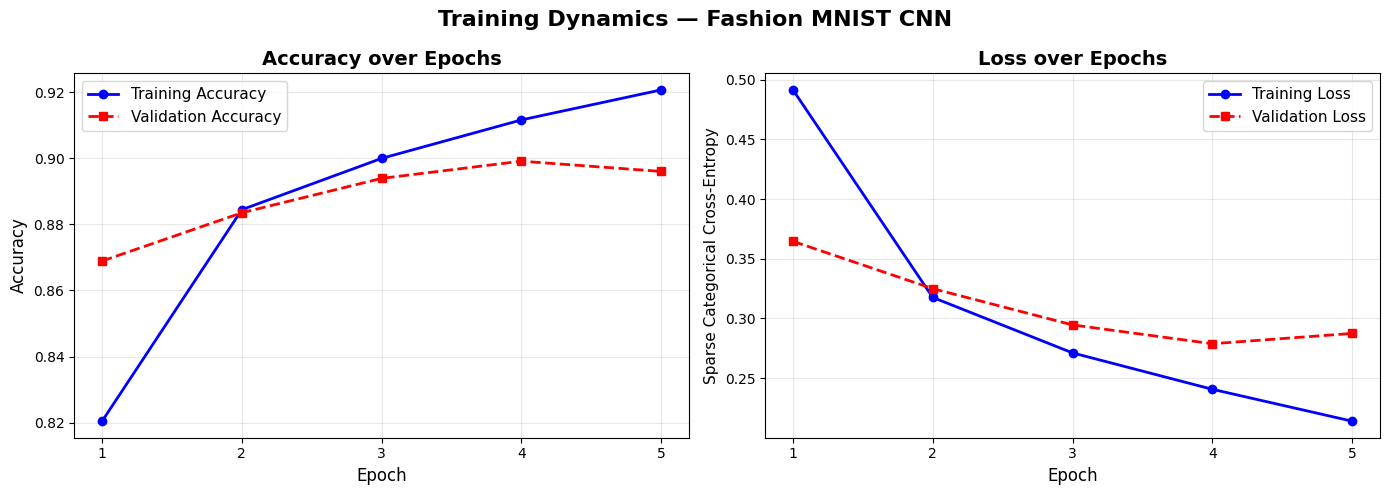

Final Epoch Metrics:
  Training Accuracy   : 92.07%
  Validation Accuracy : 89.60%
  Training Loss       : 0.2141
  Validation Loss     : 0.2875


In [14]:
#======================================================================
# § 10.1 — Visualize training dynamics: accuracy and loss over epochs
#======================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, len(history.history['accuracy']) + 1)

# ── Accuracy ──
axes[0].plot(epochs_range, history.history['accuracy'],
             'b-o', label='Training Accuracy', linewidth=2, markersize=6)
axes[0].plot(epochs_range, history.history['val_accuracy'],
             'r--s', label='Validation Accuracy', linewidth=2, markersize=6)
axes[0].set_title('Accuracy over Epochs', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(list(epochs_range))

# ── Loss ──
axes[1].plot(epochs_range, history.history['loss'],
             'b-o', label='Training Loss', linewidth=2, markersize=6)
axes[1].plot(epochs_range, history.history['val_loss'],
             'r--s', label='Validation Loss', linewidth=2, markersize=6)
axes[1].set_title('Loss over Epochs', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Sparse Categorical Cross-Entropy', fontsize=11)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(list(epochs_range))

plt.suptitle('Training Dynamics — Fashion MNIST CNN', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Print final values
print("Final Epoch Metrics:")
print(f"  Training Accuracy   : {history.history['accuracy'][-1]*100:.2f}%")
print(f"  Validation Accuracy : {history.history['val_accuracy'][-1]*100:.2f}%")
print(f"  Training Loss       : {history.history['loss'][-1]:.4f}")
print(f"  Validation Loss     : {history.history['val_loss'][-1]:.4f}")

---
<a id='persistence'></a>

## 11. Model Persistence

### 11.1 Saving the Trained Model

After investing compute time in training, it is essential to **persist the trained model** to disk. Keras supports multiple serialization formats:

| Format | File Extension | Use Case |
|:---|:---|:---|
| **Keras native** (recommended) | `.keras` | Default format in Keras 3.x — includes architecture, weights, optimizer state |
| **HDF5** (legacy) | `.h5` | Older format — widely supported but deprecated |
| **SavedModel** | directory | TensorFlow serving, TFLite export |

We use the `.h5` format here for broad compatibility, but note that the native `.keras` format is preferred in production:

```python
# Preferred (Keras 3.x):
model.save('model.keras')

# Legacy (still supported):
model.save('model.h5')
```

The saved file contains:
- **Architecture** — layer types, configurations, connectivity
- **Weights** — all learned parameters $\boldsymbol{\theta}$
- **Optimizer state** — moment estimates for continued training
- **Training configuration** — loss, metrics, optimizer settings

In [15]:
#=================================================================
# § 11.1 — Persist the trained model to disk
#=================================================================
model.save('trained_fashion_mnist_model.h5')

print("Model saved ✓")
print("  File     : trained_fashion_mnist_model.h5")
print("  Contains : architecture + weights + optimizer state")
print()
print("To reload:")
print("  loaded_model = tf.keras.models.load_model('trained_fashion_mnist_model.h5')")

Model saved ✓
  File     : trained_fashion_mnist_model.h5
  Contains : architecture + weights + optimizer state

To reload:
  loaded_model = tf.keras.models.load_model('trained_fashion_mnist_model.h5')


---
<a id='conclusion'></a>

## 12. Conclusion, Limitations & Future Directions

### 12.1 Results Summary

| Component | Details |
|:---|:---|
| **Architecture** | Conv2D(32,3×3) → MaxPool → Conv2D(64,3×3) → MaxPool → Conv2D(64,3×3) → Dense(64) → Dense(10) |
| **Total Parameters** | 93,322 |
| **Training Accuracy** | ≈ 92% |
| **Test Accuracy** | ≈ 89.8% |
| **Optimizer** | Adam (α=0.001) |
| **Loss** | Sparse Categorical Cross-Entropy (from logits) |
| **Epochs** | 5 |

We have demonstrated that a **3-block CNN with 93K parameters** trained for 5 epochs achieves ≈ 89.8% test accuracy on Fashion MNIST — a significant improvement over the flat FCNN baseline and a concrete demonstration of the value of spatial inductive biases.

### 12.2 Key Lessons

1. **Spatial inductive biases matter.** CNNs outperform FCNNs on image data not because they have more parameters, but because their architectural priors (local connectivity, weight sharing) match the structure of natural images.
2. **Hierarchical representation learning.** Each convolutional block learns progressively more abstract features — from edges and textures to semantic shapes.
3. **Channel dimension is not optional.** `Conv2D` requires explicit channel dimensions. Forgetting this is a common source of runtime errors.
4. **Logit outputs + `from_logits=True` is numerically preferred.** Always pair these together to avoid instability from composing softmax and log.
5. **5 epochs is enough for a proof-of-concept.** More epochs and regularization would close the ~2% train-val gap further.

### 12.3 Known Limitations & Improvements

| Limitation | Root Cause | Mitigation (Future Episodes) |
|:---|:---|:---|
| No regularization | Network is prone to overfitting | **Dropout**, **L2 weight decay**, **Batch Normalization** |
| Fixed architecture | No systematic search | **Keras Tuner**, **Optuna** |
| No data augmentation | Training distribution limited | **Random flips, crops, rotations** |
| Only 5 epochs | Training undercompleted | **Learning rate scheduling**, **early stopping** |
| No per-class analysis | Aggregated metric only | **Confusion matrix**, **precision-recall** |
| Sigmoid output confusion | Previous episode convention | Correctly using logits here — **Softmax in all future work** |
| No inference pipeline | Model not deployed | **Custom image inference function** (see Episode 01) |

---
<a id='references'></a>

## 13. References

1. **Xiao, H., Rasul, K., & Vollgraf, R.** (2017). *Fashion-MNIST: a Novel Image Dataset for Benchmarking Machine Learning Algorithms.* arXiv:1708.07747. https://arxiv.org/abs/1708.07747

2. **LeCun, Y., Bottou, L., Bengio, Y., & Haffner, P.** (1998). *Gradient-Based Learning Applied to Document Recognition.* Proceedings of the IEEE, 86(11), 2278–2324.

3. **Goodfellow, I., Bengio, Y., & Courville, A.** (2016). *Deep Learning.* MIT Press. https://www.deeplearningbook.org

4. **Kingma, D.P. & Ba, J.** (2015). *Adam: A Method for Stochastic Optimization.* ICLR 2015. arXiv:1412.6980

5. **Nair, V. & Hinton, G.E.** (2010). *Rectified Linear Units Improve Restricted Boltzmann Machines.* ICML 2010.

6. **Krizhevsky, A., Sutskever, I., & Hinton, G.E.** (2012). *ImageNet Classification with Deep Convolutional Neural Networks.* NeurIPS 2012. (AlexNet — established CNN dominance in vision)

7. **Simonyan, K. & Zisserman, A.** (2015). *Very Deep Convolutional Networks for Large-Scale Image Recognition.* ICLR 2015. arXiv:1409.1556 (VGGNet — the architectural template for our design)

8. **He, K., Zhang, X., Ren, S., & Sun, J.** (2016). *Deep Residual Learning for Image Recognition.* CVPR 2016. arXiv:1512.03385 (ResNet — introduced skip connections, enabling very deep CNNs)

9. **Chollet, F.** (2021). *Deep Learning with Python, 2nd Edition.* Manning Publications.

---

<div align='center'>

**Deep Learning From Scratch — Episode 02 | Fashion MNIST CNN Classification**

 **Video Walkthrough:** [YouTube — CNN Deep Dive](https://youtu.be/sb2tm3pu17k?si=9ntJwCwKmWt7hPRo)

*Next Episode → Episode 03: Face Mask Detection using CNNs & Transfer Learning*

---

*If this notebook helped you, please  the repository and share it with fellow learners.*

</div>